# Projeto Final Aprendizado de Máquina
## Aplicação de Modelos de Classificação

integrantes

- Thiago Hideki Tsutiya - 11201811680  
- Thiago de Lima Silva - 11202020228  
- João Pedro Genga Carneiro - 11201810740  
- Vinicius Hideo Miyake - 11201920257  

https://github.com/ttsutiya/aprendizado-de-maquina-ufabc

## Análise de Plantas Comestíveis

## Objetivo

Este projeto tem como objetivo analisar características de plantas comestíveis e construir modelos capazes de prever a necessidade de água com base em outras variáveis.

## Pipeline do projeto

O projeto foi dividido em 4 etapas principais:

1. Coleta dos dados
2. Limpeza e pré-processamento
3. Análise exploratória
4. Modelagem preditiva

## 1. Coleta dos dados


Os dados utilizados neste projeto foram obtidos a partir do dataset [Edibe Plants Database](https://rfordatascience.github.io/tidytuesday/data/2026/2026-02-03/readme.html)

A base contém informações sobre plantas comestíveis, incluindo características como:
- necessidade de água
- nutrientes requeridos
- classe de temperatura
- grupo de cultivação

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-02-03/edible_plants.csv")
df.to_csv("editable_plants.csv")

## 2. Limpeza e processamento


In [3]:
editable_plants = pd.read_csv("editable_plants.csv", index_col=0)
len(editable_plants)

140

In [4]:
editable_plants.columns

Index(['taxonomic_name', 'common_name', 'cultivation', 'sunlight', 'water',
       'preferred_ph_lower', 'preferred_ph_upper', 'nutrients', 'soil',
       'season', 'temperature_class', 'temperature_germination',
       'temperature_growing', 'days_germination', 'days_harvest',
       'nutritional_info', 'energy', 'sensitivities', 'description',
       'requirements'],
      dtype='str')

In [5]:
editable_plants.iloc[0, :]

taxonomic_name                                                 Pisum sativum
common_name                                                              Pea
cultivation                                                           Legume
sunlight                                                            Full sun
water                                                              Very High
preferred_ph_lower                                                       6.0
preferred_ph_upper                                                       7.5
nutrients                                                             Medium
soil                                                                   Loamy
season                                                                Annual
temperature_class                                                 Half hardy
temperature_germination                                                   24
temperature_growing                                                     4-24

In [6]:
for col in editable_plants.columns:
    num = len(editable_plants[col].unique())
    print(f"name: {col:<25} num: {num:<5}")

name: taxonomic_name            num: 123  
name: common_name               num: 140  
name: cultivation               num: 12   
name: sunlight                  num: 6    
name: water                     num: 8    
name: preferred_ph_lower        num: 6    
name: preferred_ph_upper        num: 8    
name: nutrients                 num: 7    
name: soil                      num: 34   
name: season                    num: 12   
name: temperature_class         num: 6    
name: temperature_germination   num: 21   
name: temperature_growing       num: 32   
name: days_germination          num: 17   
name: days_harvest              num: 60   
name: nutritional_info          num: 11   
name: energy                    num: 10   
name: sensitivities             num: 11   
name: description               num: 129  
name: requirements              num: 128  


Foi identificado que algumas plantas possuíam o mesmo `taxonomic_name`, mas contendo um `common_name` diferente e.g. Onion, Onion (Autumn Planted), Onion (Red).

Ao invés de remover todos os registros duplicados (o que causaria perda significativa de dados), optou-se por manter apenas a primeira ocorrência, visto que a maioria das instâncias contiam o mesmo atributo, ou variam muito pouco entre si.

In [7]:
mask = editable_plants.duplicated(subset=["taxonomic_name"], keep=False)
index = editable_plants[mask].sort_values("taxonomic_name").index
len(index)

27

In [8]:
editable_plants.loc[index]

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements
55,Allium cepa,Onions (Red),Allium,Full sun/partial shade,Medium,6.0,7.0,Medium,"Loamy, clay and sandy",NaN,Very hardy,24,NaN,6,90-130,NaN,NaN,NaN,Onion is a multi layered bulb which has a shar...,Onions can be grown from either seed or a set ...
53,Allium cepa,Onion (Autumn planted),Allium,Full sun/partial shade,Medium,6.0,7.0,Medium,"Loamy, clay and sandy",NaN,Hardy,24,NaN,6,90-130,NaN,NaN,NaN,Onion is a multi layered bulb which has a shar...,Onions can be grown from either seed or a set ...
52,Allium cepa,Onion,Allium,Full sun/partial shade,Medium,6.0,7.0,Medium,"Loamy, clay and sandy",NaN,Hardy,24,10-35,6,90-130,NaN,NaN,NaN,Onion is a multi layered bulb which has a shar...,Onions can be grown from either seed or a set ...
67,Allium cepa (var. aggregatum),Shallots,Allium,Full sun,Medium,6.0,7.0,Low,Loamy,NaN,Very hardy,24,NaN,21,90-,NaN,NaN,NaN,"Similar to onions, but are smaller and grow in...",Easy to grow and will do well in any well-drai...
73,Allium cepa (var. aggregatum),Spring Onion / Scallions,Allium,Full sun/partial shade,Medium,6.0,7.0,Low,NaN,NaN,Very hardy,24,NaN,6,60-,NaN,NaN,NaN,Spring onion have a mild flavour ideal for usi...,Can be sown directly where they are to be grow...
32,Brassica oleracea,Calabrese,Brassica,partial shade,Medium,6.0,7.0,High,Loamy and sandy,NaN,Tender,24,7-30,7,55-85,NaN,NaN,NaN,"Often described as broccoli, calabrese has one...",This cool-season crop grows best when daytime ...
31,Brassica oleracea,Cabbage (Summer),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
29,Brassica oleracea,Cabbage (Spring red),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
30,Brassica oleracea,Cabbage (Summer red),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
27,Brassica oleracea,Cabbage (Autumn),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...


In [9]:
editable_plants.loc[editable_plants.taxonomic_name == "Allium cepa"]

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements
52,Allium cepa,Onion,Allium,Full sun/partial shade,Medium,6.0,7.0,Medium,"Loamy, clay and sandy",NaN,Hardy,24,10-35,6,90-130,NaN,NaN,NaN,Onion is a multi layered bulb which has a shar...,Onions can be grown from either seed or a set ...
53,Allium cepa,Onion (Autumn planted),Allium,Full sun/partial shade,Medium,6.0,7.0,Medium,"Loamy, clay and sandy",NaN,Hardy,24,NaN,6,90-130,NaN,NaN,NaN,Onion is a multi layered bulb which has a shar...,Onions can be grown from either seed or a set ...
55,Allium cepa,Onions (Red),Allium,Full sun/partial shade,Medium,6.0,7.0,Medium,"Loamy, clay and sandy",NaN,Very hardy,24,NaN,6,90-130,NaN,NaN,NaN,Onion is a multi layered bulb which has a shar...,Onions can be grown from either seed or a set ...


In [10]:
editable_plants.loc[editable_plants.taxonomic_name == "Brassica oleracea"]

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements
4,Brassica oleracea,Cabbage (Spring),Legume,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...
26,Brassica oleracea,Cabbage (Autumn red),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
27,Brassica oleracea,Cabbage (Autumn),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
29,Brassica oleracea,Cabbage (Spring red),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
30,Brassica oleracea,Cabbage (Summer red),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
31,Brassica oleracea,Cabbage (Summer),Brassica,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,60-110,NaN,NaN,NaN,"Also known as headed cabbage, grown for it's t...",Cabbage is a cool-season crop best planted in ...
32,Brassica oleracea,Calabrese,Brassica,partial shade,Medium,6.0,7.0,High,Loamy and sandy,NaN,Tender,24,7-30,7,55-85,NaN,NaN,NaN,"Often described as broccoli, calabrese has one...",This cool-season crop grows best when daytime ...


Iremos manter somente a primeira instancia de cada `taxonomic_name`.

In [13]:
mask = editable_plants.duplicated(subset=["taxonomic_name"], keep="first")
editable_plants = editable_plants[~mask]
len(editable_plants)

123

 ### 2.2 Remoção de colunas irrelevantes

Colunas textuais como `description`, `nutritional_info`, `sensitivities` e `requirements` foram removidas, pois possuem natureza descritiva e não estruturada, dificultando sua utilização em modelos tradicionais.


In [14]:
editable_plants.iloc[0:5][
    ["sensitivities", "nutritional_info", "description", "requirements"]
]

,sensitivities,nutritional_info,description,requirements
0,Drought intolerant,"A good source of vitamin K, manganese, and die...","The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten..."
1,Drought intolerant,"A good source of protein, thiamine, and ribofl...",Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar..."
2,Drought intolerant,"A good source of protein, thiamine, and ribofl...","French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar..."
3,Drought intolerant,"A good source of vitamin-B6 (pyridoxine), thia...",Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...
4,Particularly vulnerable to pests. Do not grow ...,"A very good source of manganese, dietary fibre...",Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...


In [15]:
editable_plants.iloc[4].sensitivities

'Particularly vulnerable to pests. Do not grow if soil is too acidic.'

In [16]:
editable_plants = editable_plants.drop(
    columns=[
        "nutritional_info",
        "description",
        "requirements",
        "sensitivities",
    ]
)

In [17]:
editable_plants.soil.unique()

<StringArray>
[                                                           'Loamy',
                                                   'Loamy and clay',
                                     'Any well-drained and fertile',
                                                   'Sand/loam/clay',
                                                  'Loamy and sandy',
                                                            'Sandy',
                                           'Chalky, sandy and clay',
                                         'Well-drained and fertile',
                                                  'Sandy and loamy',
                                            'Loamy and potting mix',
                                                                nan,
                                   'Sandy, clay and peat-rich soil',
                                            'Loamy, clay and sandy',
                                                  'Loamy and silty',
 'Well-drained, fert

O que eh um solo well-drained e fertile? Sao propriedades de qualquer solo?
Devido ao tipos de solos como "high in organic matter", "rich-moist soil", "peat-rich soil", entre outros decidimos não usar essa coluna.

In [18]:
editable_plants = editable_plants.drop(columns=["soil"])

## 2.3 Tratamento de valores ausentes

Foi realizada uma verificação de valores nulos no dataset. Como não havia uma estratégia confiável para imputação desses dados com base nas demais variáveis, optou-se pela remoção das colunas que apresentavam valores ausentes.

In [19]:
check_null = editable_plants.isnull().sum()
check_null / len(editable_plants)

taxonomic_name             0.000000
common_name                0.000000
cultivation                0.000000
sunlight                   0.000000
water                      0.000000
preferred_ph_lower         0.000000
preferred_ph_upper         0.000000
nutrients                  0.000000
season                     0.512195
temperature_class          0.000000
temperature_germination    0.284553
temperature_growing        0.609756
days_germination           0.284553
days_harvest               0.219512
energy                     0.902439
dtype: float64

Algumas colunas estão completas, enquanto outras apresentam uma falta considerável de dados. Como não é possível preenchê-las utilizando as demais colunas, vamos simplesmente removê-las.

In [21]:
drop_cols = check_null[check_null > 0].index
editable_plants = editable_plants.drop(columns=drop_cols)

## 2.4 Transformação de variáveis categóricas

Variáveis categóricas foram convertidas para formato numérico, permitindo sua utilização em modelos de machine learning.

Para variáveis sem ordem natural, foi utilizado o método de one-hot encoding. Já para variáveis ordinais, foi realizado um mapeamento manual, preservando a relação de ordem entre os valores.

In [22]:
editable_plants.columns

Index(['taxonomic_name', 'common_name', 'cultivation', 'sunlight', 'water',
       'preferred_ph_lower', 'preferred_ph_upper', 'nutrients',
       'temperature_class'],
      dtype='str')

In [23]:
editable_plants.iloc[0]

taxonomic_name        Pisum sativum
common_name                     Pea
cultivation                  Legume
sunlight                   Full sun
water                     Very High
preferred_ph_lower              6.0
preferred_ph_upper              7.5
nutrients                    Medium
temperature_class        Half hardy
Name: 0, dtype: object

In [24]:
editable_plants.cultivation.unique()

<StringArray>
[        'Legume',       'Brassica',       'Cucurbit',          'Salad',
  'Miscellaneous',     'Solanaceae',   'Umbelliferae',         'Allium',
 'Chenopodiaceae',        'Solanum',      'Lamiaceae',      'Brassicas']
Length: 12, dtype: str

In [25]:
editable_plants.cultivation = editable_plants.cultivation.str.lower().str.strip()
editable_plants["cultivation"] = editable_plants.cultivation.replace(
    {"brassicas": "brassica"}
)

In [26]:
editable_plants = pd.get_dummies(
    editable_plants, columns=["cultivation"], drop_first=True
)

In [27]:
editable_plants.sunlight.unique()

<StringArray>
[                          'Full sun',  'Full sun/partial shade/full shade',
             'Full sun/partial shade',                      'Partial shade',
 'full sun/partial shade/ full shade']
Length: 5, dtype: str

In [28]:
editable_plants.sunlight = editable_plants.sunlight.replace(
    {"full sun/partial shade/ full shade": "Full sun/partial shade/full shade"}
)

In [29]:
editable_plants.sunlight = editable_plants.sunlight.str.lower().str.strip()
editable_plants = pd.get_dummies(editable_plants, columns=["sunlight"], drop_first=True)

## 2.5 Codificação de variáveis ordinais

Variáveis como water, nutrients e temperature_class possuem uma ordem natural entre seus valores (por exemplo: baixo, médio, alto).

Para preservar essa relação, foi realizado um mapeamento manual para valores numéricos.

Essa abordagem permite que os modelos capturem corretamente a progressão entre os níveis, ao contrário de técnicas como one-hot encoding, que tratariam cada valor como independente.

In [31]:
editable_plants.water = editable_plants.water.str.lower().str.strip()
editable_plants.water.unique()

<StringArray>
['very high', 'medium', 'very low', 'high', 'low']
Length: 5, dtype: str

In [32]:
water_map = {
    "low": 1,
    "very low": 2,
    "medium": 3,
    "high": 4,
    "very high": 5,
}

editable_plants["water_code"] = editable_plants.water.map(water_map)

In [33]:
editable_plants.nutrients = editable_plants.nutrients.str.lower().str.strip()
editable_plants.nutrients.unique()

<StringArray>
['medium', 'high', 'low', 'medium to high']
Length: 4, dtype: str

In [34]:
mask = editable_plants.nutrients == "high potassium fertiliser every 2 weeks."
editable_plants.loc[mask, "nutrients"] = "high"

In [35]:
nutrients_map = {
    "low": 1,
    "medium": 2,
    "medium to high": 3,
    "high": 4,
}

editable_plants["nutrients_code"] = editable_plants.nutrients.map(nutrients_map)

In [38]:
editable_plants.temperature_class = editable_plants.temperature_class.str.lower().str.strip()
editable_plants.temperature_class.unique()

<StringArray>
['half hardy', 'tender', 'hardy', 'very hardy', 'very tender']
Length: 5, dtype: str

In [39]:
mask = editable_plants.temperature_class == "very hard"
editable_plants.loc[mask, "temperature_class"] = "very hardy"

In [40]:
temperature_class_map = {
    "very tender": 1,
    "tender": 2,
    "half hardy": 3,
    "hardy": 4,
    "very hardy": 5,
}

editable_plants["temperature_class_code"] = editable_plants.temperature_class.map(
    temperature_class_map
)

In [41]:
editable_plants.to_csv("clean_editable_plants.csv", index=False)

## 3 Análise Exploratória

A análise exploratória foi realizada com o objetivo de compreender a distribuição das variáveis e identificar possíveis relações entre elas.

Foram utilizados gráficos para visualizar padrões e tendências no conjunto de dados.

## Distribuição de Variáveis

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

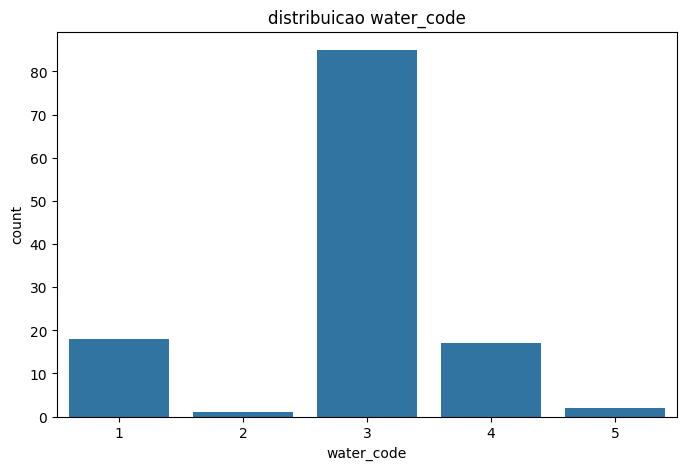

In [43]:
df = pd.read_csv("clean_editable_plants.csv")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="water_code")
plt.title("distribuicao water_code")
plt.show()

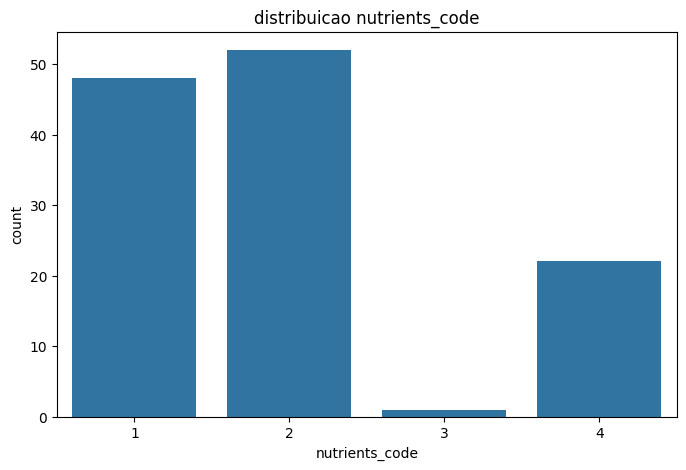

In [44]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="nutrients_code")
plt.title("distribuicao nutrients_code")
plt.show()

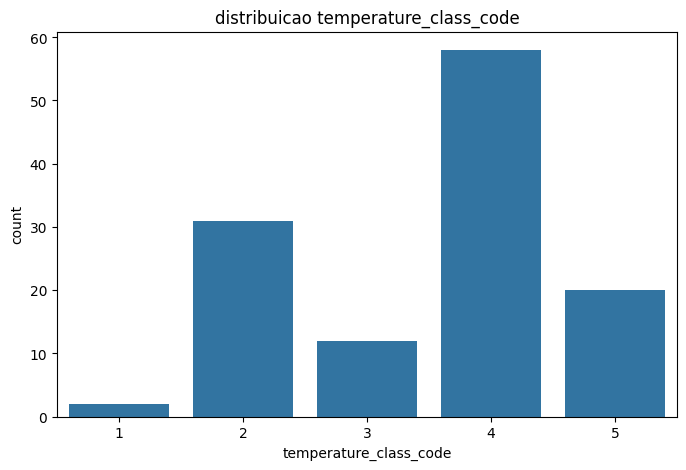

In [45]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="temperature_class_code")
plt.title("distribuicao temperature_class_code")
plt.show()

### Correlação entre variáveis

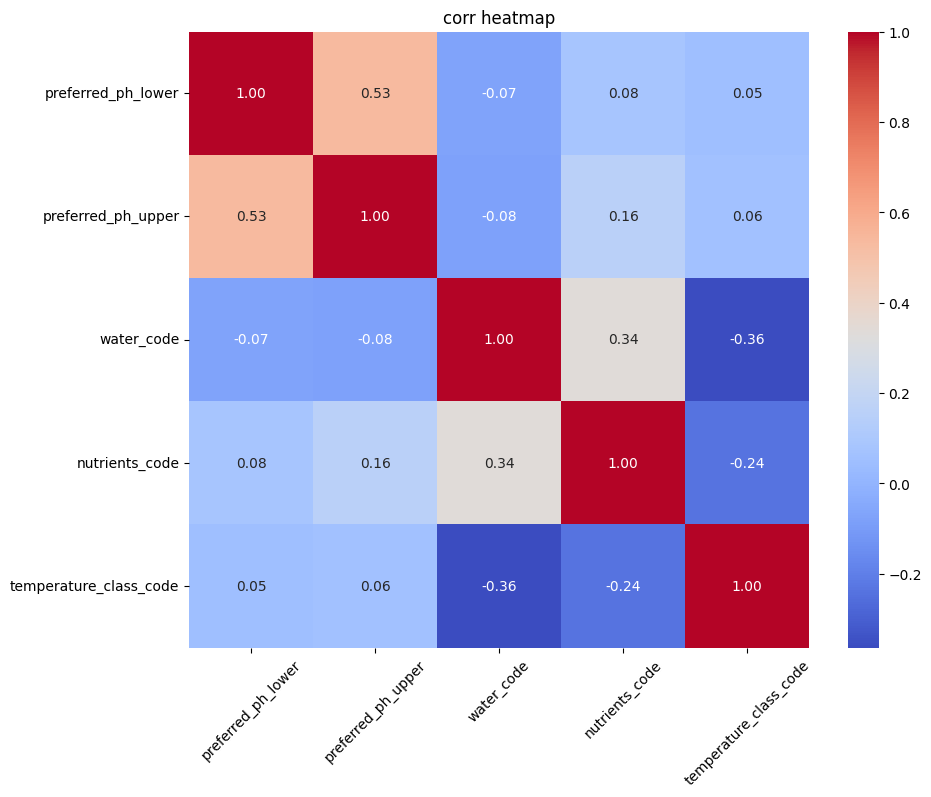

In [48]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("corr heatmap")
plt.xticks(rotation=45)
plt.show()

### Relação com variável alvo

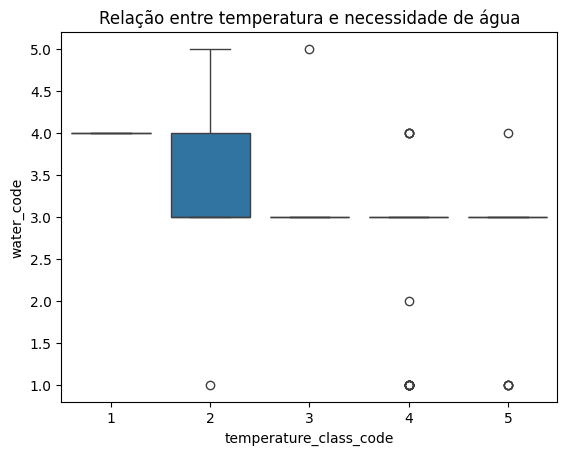

In [49]:
sns.boxplot(data=df, x="temperature_class_code", y="water_code")
plt.title("Relação entre temperatura e necessidade de água")
plt.show()

## 4 Modelagem
O objetivo desta etapa é construir modelos capazes de prever a necessidade de água (water_code) com base nas demais variáveis.

### Modelos utilizados:
- Regressão Logística
- K-Nearest Neighbors (KNN)
- Random Forest

### Validação:
- Leave-One-Out Cross Validation (LOOCV)

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, randint
from sklearn.model_selection import (
    LeaveOneOut,
    RandomizedSearchCV,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

### 4.1 Carregamento e Pré-processamento dos Dados

- Lemos o dataset
- Separamos os nomes das plantas
- Removemos colunas irrelevantes
- Definimos variáveis de entrada (X) e saída (y)

In [52]:
df = pd.read_csv("clean_editable_plants.csv")

In [53]:
nomes_plantas = df["common_name"]

In [54]:
df = df.drop(
    columns=[
        "taxonomic_name",
        "common_name",
        "water",
        "nutrients",
        "temperature_class",
    ]
)

In [55]:
y = df["water_code"]
X = df.drop(
    columns=[
        "water_code",
    ]
)

loo = LeaveOneOut()

### 4.2 Regressão Logística


In [56]:
log_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("log_reg", LogisticRegression(max_iter=1000, random_state=0)),
    ]
)

log_param_dist = {"log_reg__C": loguniform(1e-3, 1e3)}

random_search = RandomizedSearchCV(
    estimator=log_pipe,
    param_distributions=log_param_dist,
    n_iter=100,
    cv=loo,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0,
)

In [57]:
random_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'log_reg__C': <scipy.stats....x7f3694999400>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold."

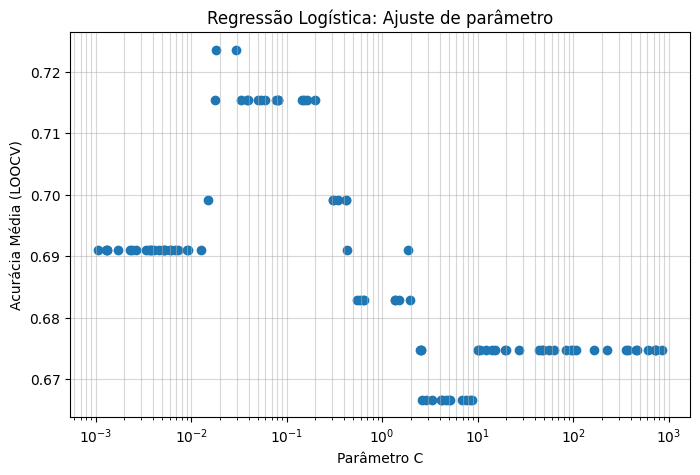

In [58]:
c_values = random_search.cv_results_["param_log_reg__C"].data.astype(float)
scores = random_search.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.scatter(c_values, scores)
plt.xscale("log")
plt.xlabel("Parâmetro C")
plt.ylabel("Acurácia Média (LOOCV)")
plt.title("Regressão Logística: Ajuste de parâmetro")
plt.grid(True, which="both", alpha=0.5)
plt.show()

In [59]:
print(
    f"Melhor parâmetro (C = 1/lambda): {random_search.best_params_['log_reg__C']:.4f}"
)
print(f"Lambda: {1 / random_search.best_params_['log_reg__C']:.4f}")
print(f"Melhor acurácia LOOCV: {random_search.best_score_:.4f}")

Melhor parâmetro (C = 1/lambda): 0.0183
Lambda: 54.6644
Melhor acurácia LOOCV: 0.7236


No EDA notou-se que uma grande quantidade de dados pertencem ao `water_code=3`. Onde 83 dos 123 dados do dataset (~67%) pertencem a esse grupo.

Isso significa que os nosso modelos podem estar apenas chutando o grupo 3 para qualquer planta. Para isso vamos analisar a matriz de confusão dos modelos.

In [60]:
best_log_model = random_search.best_estimator_
y_pred_log = cross_val_predict(best_log_model, X, y, cv=loo, n_jobs=-1)

In [61]:
print(classification_report(y, y_pred_log, zero_division=0))

              precision    recall  f1-score   support

           1       0.75      0.17      0.27        18
           2       0.00      0.00      0.00         1
           3       0.72      1.00      0.84        85
           4       1.00      0.06      0.11        17
           5       0.00      0.00      0.00         2

    accuracy                           0.72       123
   macro avg       0.49      0.25      0.24       123
weighted avg       0.75      0.72      0.63       123



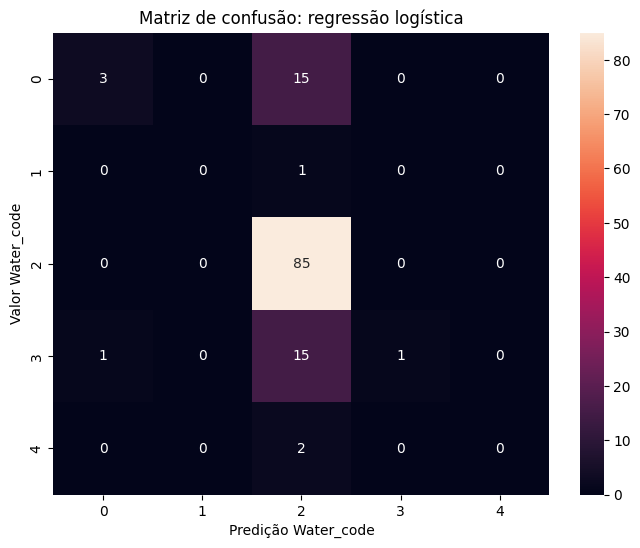

In [62]:
cm = confusion_matrix(y, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True)
plt.xlabel("Predição Water_code")
plt.ylabel("Valor Water_code")
plt.title("Matriz de confusão: regressão logística")
plt.show()

Para tentar arrumar isso vamos usar o modo `balanced` na regressão logística, aumentando a penalidade ao errar os grupos menores.

In [63]:
log_pipe_balanced = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "log_reg",
            LogisticRegression(max_iter=1000, random_state=0, class_weight="balanced"),
        ),
    ]
)

random_search_balanced = RandomizedSearchCV(
    estimator=log_pipe_balanced,
    param_distributions=log_param_dist,
    n_iter=100,
    cv=loo,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0,
)

In [64]:
random_search_balanced.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'log_reg__C': <scipy.stats....x7f3694999400>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold."

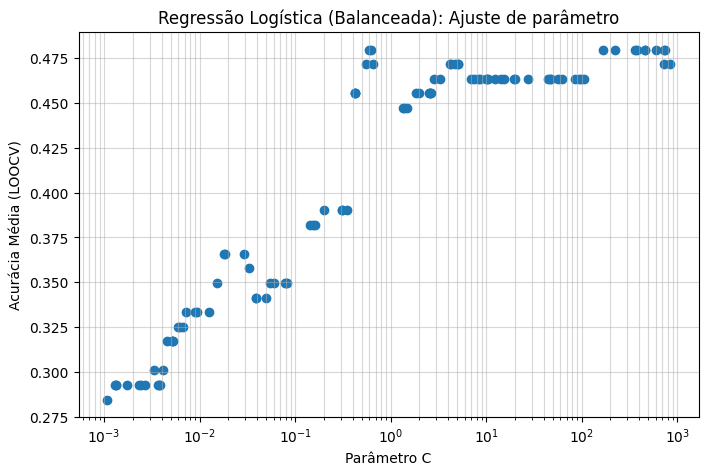

In [65]:
c_values_balanced = random_search_balanced.cv_results_["param_log_reg__C"].data.astype(
    float
)
scores_balanced = random_search_balanced.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.scatter(c_values_balanced, scores_balanced)
plt.xscale("log")
plt.xlabel("Parâmetro C")
plt.ylabel("Acurácia Média (LOOCV)")
plt.title("Regressão Logística (Balanceada): Ajuste de parâmetro")
plt.grid(True, which="both", alpha=0.5)
plt.show()

In [66]:
print(
    f"Melhor parâmetro (C = 1/lambda): {random_search_balanced.best_params_['log_reg__C']:.4f}"
)
print(f"Lambda: {1 / random_search_balanced.best_params_['log_reg__C']:.4f}")
print(f"Melhor acurácia LOOCV: {random_search_balanced.best_score_:.4f}")

Melhor parâmetro (C = 1/lambda): 224.2012
Lambda: 0.0045
Melhor acurácia LOOCV: 0.4797


In [67]:
best_log_balanced = random_search_balanced.best_estimator_
y_pred_log_balanced = cross_val_predict(best_log_balanced, X, y, cv=loo, n_jobs=-1)

In [69]:
print(classification_report(y, y_pred_log_balanced, zero_division=0))

              precision    recall  f1-score   support

           1       0.39      0.72      0.51        18
           2       0.00      0.00      0.00         1
           3       0.76      0.46      0.57        85
           4       0.22      0.41      0.29        17
           5       0.00      0.00      0.00         2

    accuracy                           0.48       123
   macro avg       0.28      0.32      0.27       123
weighted avg       0.62      0.48      0.51       123



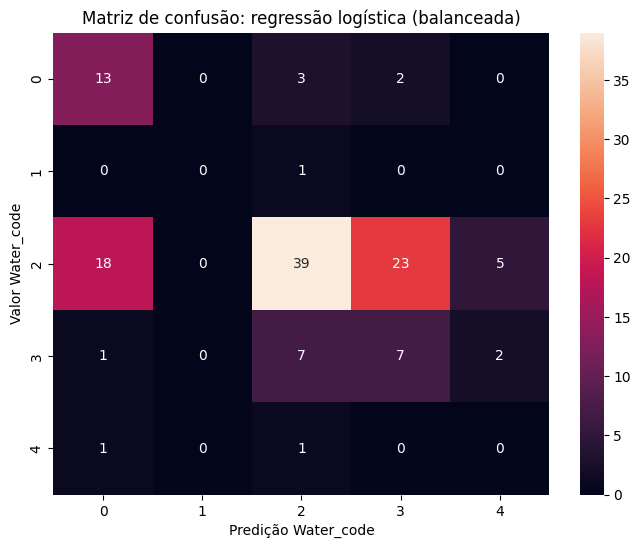

In [68]:
cm_balanced = confusion_matrix(y, y_pred_log_balanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True)
plt.xlabel("Predição Water_code")
plt.ylabel("Valor Water_code")
plt.title("Matriz de confusão: regressão logística (balanceada)")
plt.show()

### 4.3 KNN Regression

In [70]:
knn_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]
)

knn_param_grid = {"knn__n_neighbors": np.arange(1, 31)}

knn_grid = GridSearchCV(
    estimator=knn_pipe, param_grid=knn_param_grid, cv=loo, scoring="accuracy", n_jobs=-1
)

In [71]:
knn_grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': array([ 1, 2..., 28, 29, 30])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

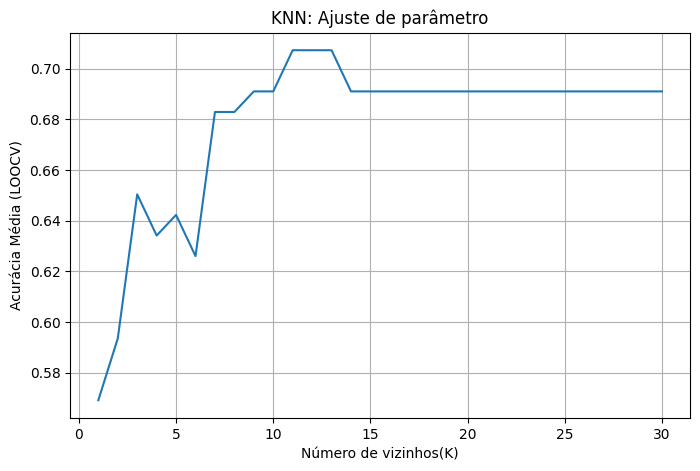

In [72]:
k_values = knn_param_grid["knn__n_neighbors"]
knn_scores = knn_grid.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_scores)
plt.xlabel("Número de vizinhos(K)")
plt.ylabel("Acurácia Média (LOOCV)")
plt.title("KNN: Ajuste de parâmetro")
plt.grid(True, which="both")
plt.show()

In [73]:
print(f"Melhor K: {knn_grid.best_params_['knn__n_neighbors']}")
print(f"Melhor acurácia KNN: {knn_grid.best_score_:.4f}\n")

Melhor K: 11
Melhor acurácia KNN: 0.7073



In [74]:
best_knn = knn_grid.best_estimator_
y_pred_knn = cross_val_predict(best_knn, X, y, cv=loo, n_jobs=-1)

In [75]:
print(classification_report(y, y_pred_knn, zero_division=0))

              precision    recall  f1-score   support

           1       0.67      0.11      0.19        18
           2       0.00      0.00      0.00         1
           3       0.71      0.99      0.82        85
           4       1.00      0.06      0.11        17
           5       0.00      0.00      0.00         2

    accuracy                           0.71       123
   macro avg       0.47      0.23      0.23       123
weighted avg       0.72      0.71      0.61       123



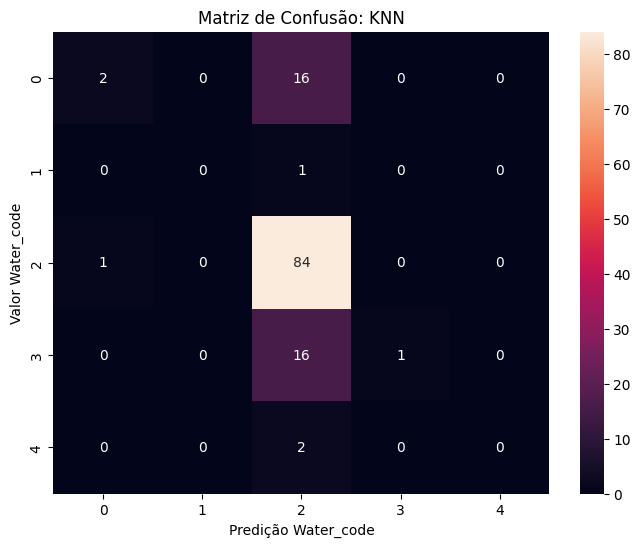

In [76]:
cm_knn = confusion_matrix(y, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True)
plt.xlabel("Predição Water_code")
plt.ylabel("Valor Water_code")
plt.title("Matriz de Confusão: KNN")
plt.show()

Para o kNN, em vez de ter um peso uniform para todos os vizinhos, iremos dar mais peso aos vizinhos próximos.

In [77]:
knn_pipe_dist = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(weights="distance")),
    ]
)

knn_grid_dist = GridSearchCV(
    estimator=knn_pipe_dist,
    param_grid=knn_param_grid,
    cv=loo,
    scoring="accuracy",
    n_jobs=-1,
)

In [78]:
knn_grid_dist.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'distance'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': array([ 1, 2..., 28, 29, 30])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

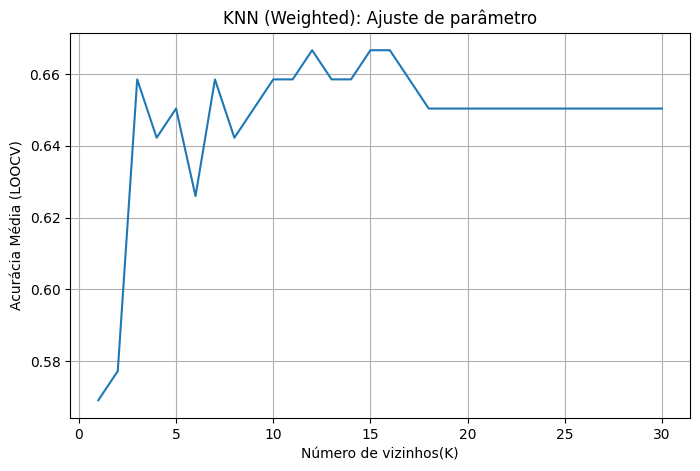

In [79]:
k_values = knn_param_grid["knn__n_neighbors"]
knn_scores_dist = knn_grid_dist.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_scores_dist)
plt.xlabel("Número de vizinhos(K)")
plt.ylabel("Acurácia Média (LOOCV)")
plt.title("KNN (Weighted): Ajuste de parâmetro")
plt.grid(True, which="both")
plt.show()

In [80]:
print(f"Melhor K: {knn_grid_dist.best_params_['knn__n_neighbors']}")
print(f"Melhor acurácia KNN: {knn_grid_dist.best_score_:.4f}\n")

Melhor K: 12
Melhor acurácia KNN: 0.6667



In [81]:
best_knn_dist = knn_grid_dist.best_estimator_
y_pred_knn_dist = cross_val_predict(best_knn_dist, X, y, cv=loo, n_jobs=-1)

In [82]:
print(classification_report(y, y_pred_knn_dist, zero_division=0))

              precision    recall  f1-score   support

           1       0.36      0.22      0.28        18
           2       0.00      0.00      0.00         1
           3       0.71      0.91      0.80        85
           4       0.25      0.06      0.10        17
           5       0.00      0.00      0.00         2

    accuracy                           0.67       123
   macro avg       0.27      0.24      0.23       123
weighted avg       0.58      0.67      0.60       123



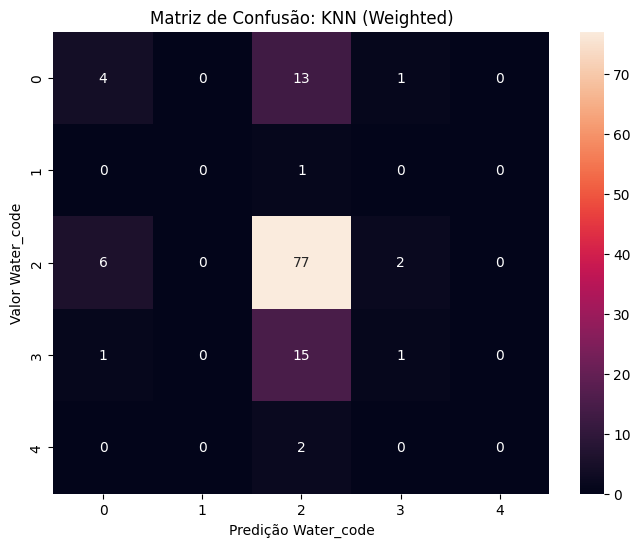

In [83]:
cm_knn = confusion_matrix(y, y_pred_knn_dist)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True)
plt.xlabel("Predição Water_code")
plt.ylabel("Valor Water_code")
plt.title("Matriz de Confusão: KNN (Weighted)")
plt.show()

### 4.4 Random forest

In [84]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)

rf_param_dist = {
    "max_depth": randint(2, 30),
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=loo,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0,
)

In [85]:
rf_random.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'max_depth': <scipy.stats....x7f3697d41160>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",L

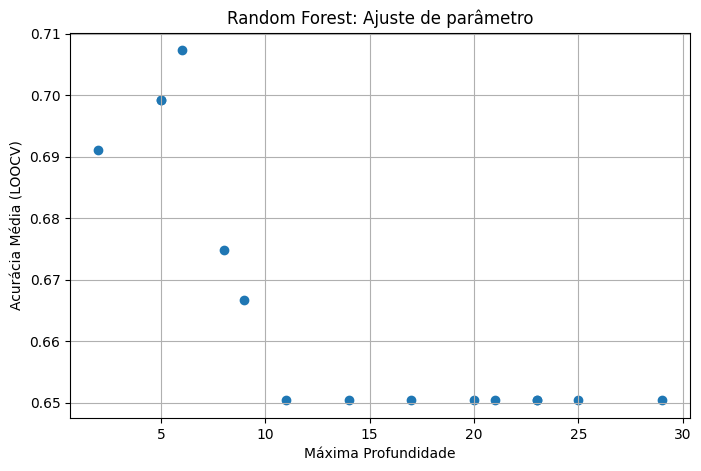

In [86]:
depth_vals = rf_random.cv_results_["param_max_depth"].data.astype(int)
rf_scores = rf_random.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.scatter(depth_vals, rf_scores)
plt.xlabel("Máxima Profundidade")
plt.ylabel("Acurácia Média (LOOCV)")
plt.title("Random Forest: Ajuste de parâmetro")
plt.grid(True)
plt.show()

In [87]:
print(f"Melhor Profundidade: {rf_random.best_params_['max_depth']}")
print(f"Melhor acurácia RF: {rf_random.best_score_:.4f}")

Melhor Profundidade: 6
Melhor acurácia RF: 0.7073


Para o random forest, iremos usar o `balanced_subsample` que faz um balanceamento no sample coletado para cada árvore.

In [88]:
best_rf = rf_random.best_estimator_
y_pred_rf_random = cross_val_predict(best_rf, X, y, cv=loo, n_jobs=-1)

In [89]:
print(classification_report(y, y_pred_rf_random, zero_division=0))

              precision    recall  f1-score   support

           1       0.75      0.17      0.27        18
           2       0.00      0.00      0.00         1
           3       0.72      0.98      0.83        85
           4       0.33      0.06      0.10        17
           5       0.00      0.00      0.00         2

    accuracy                           0.71       123
   macro avg       0.36      0.24      0.24       123
weighted avg       0.65      0.71      0.62       123



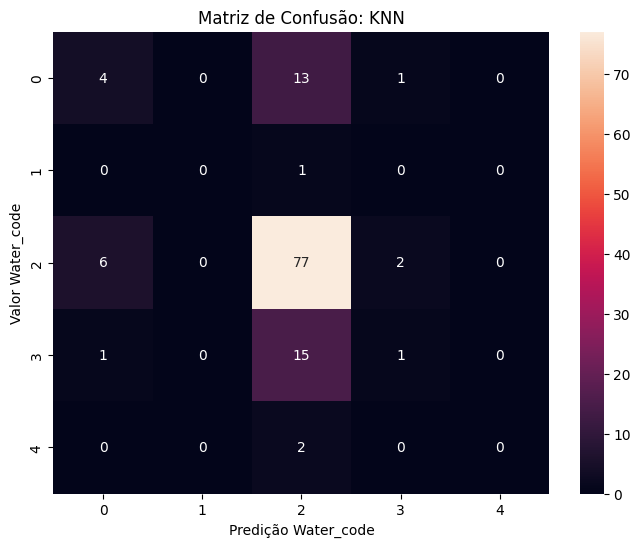

In [90]:
cm_rf = confusion_matrix(y, y_pred_rf_random)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True)
plt.xlabel("Predição Water_code")
plt.ylabel("Valor Water_code")
plt.title("Matriz de Confusão: KNN")
plt.show()

In [91]:
rf_balanced = RandomForestClassifier(
    n_estimators=100, random_state=0, class_weight="balanced_subsample"
)

rf_random_balanced = RandomizedSearchCV(
    estimator=rf_balanced,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=loo,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0,
)

In [92]:
rf_random_balanced.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'max_depth': <scipy.stats....x7f3697d41160>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",L

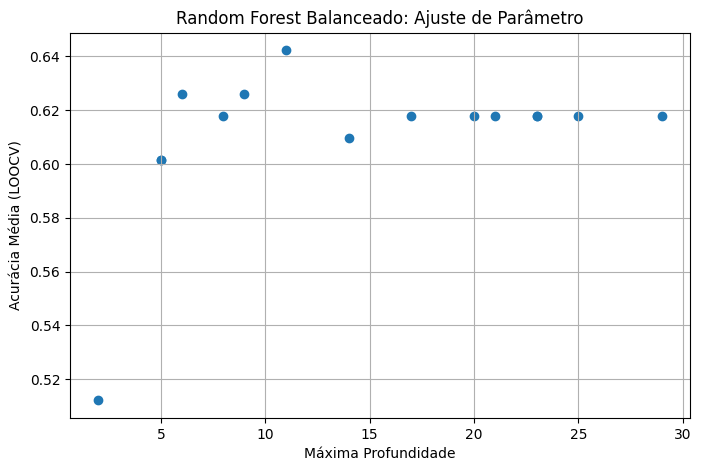

In [98]:
depth_vals_balanced = rf_random_balanced.cv_results_["param_max_depth"].data.astype(int)
rf_scores_balanced = rf_random_balanced.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.scatter(depth_vals_balanced, rf_scores_balanced)
plt.xlabel("Máxima Profundidade")
plt.ylabel("Acurácia Média (LOOCV)")
plt.title("Random Forest Balanceado: Ajuste de Parâmetro")
plt.grid(True)
plt.show()

In [94]:
print(f"Melhor Profundidade: {rf_random_balanced.best_params_['max_depth']}")
print(f"Melhor acurácia RF: {rf_random_balanced.best_score_:.4f}")

Melhor Profundidade: 11
Melhor acurácia RF: 0.6423


In [95]:
best_rf_balanced = rf_random_balanced.best_estimator_
y_pred_rf_random_balanced = cross_val_predict(best_rf_balanced, X, y, cv=loo, n_jobs=-1)

In [96]:
print(classification_report(y, y_pred_rf_random_balanced, zero_division=0))

              precision    recall  f1-score   support

           1       0.44      0.44      0.44        18
           2       0.00      0.00      0.00         1
           3       0.73      0.82      0.77        85
           4       0.12      0.06      0.08        17
           5       0.00      0.00      0.00         2

    accuracy                           0.64       123
   macro avg       0.26      0.27      0.26       123
weighted avg       0.59      0.64      0.61       123



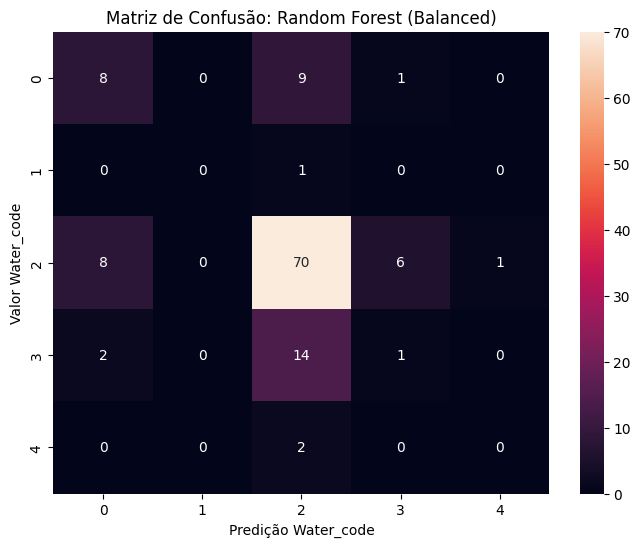

In [97]:
cm_rf_balanced = confusion_matrix(y, y_pred_rf_random_balanced)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_balanced, annot=True)
plt.xlabel("Predição Water_code")
plt.ylabel("Valor Water_code")
plt.title("Matriz de Confusão: Random Forest (Balanced)")
plt.show()